# Report 1 — Preliminary Analysis, Descriptive Statistics, and Visualizations
## Selective Attention Game Validation Study

**Study design:** 2 × 2 Mixed Factorial  
**Between-subjects factor:** Target Load (Single vs. Multiple)  
**Within-subjects factor:** Modality (Lab vs. Game)  
**N = 37** (Group A: Single Target, n = 21, IDs 1–21 | Group B: Multiple Target, n = 16, IDs 22–37)  
**Dependent variables:** Reaction Time (RT, seconds) · Accuracy (proportion 0–1)

---

### Research Questions
| RQ | Question |
|---|---|
| RQ1 — Concurrent Validity | Is there a significant positive correlation between Game and Lab performance? |
| RQ2 — Load Effect | Is performance significantly worse in the Multiple Target condition? |
| RQ3 — Modality Effect | Does the gamified interface significantly alter performance vs. the lab? |
| RQ4 — Level Effect | Does performance change across game levels (learning / fatigue)? |

---

### Notebook Structure
1. Imports and Setup  
2. Data Loading and Inspection  
3. Data Cleaning  
4. Descriptive Statistics (M, SD across all 4 cells)  
5. Visualizations  
   - 5.1 RT Distributions per Condition (Histogram + KDE)  
   - 5.2 Accuracy Distributions per Condition (Histogram + KDE)  
   - 5.3 Group Means with 95% CI (Bar Chart)  
   - 5.4 Lab vs. Game per Participant (Scatter — RQ1)  
6. Normality Checks (Shapiro-Wilk)  
7. Inferential Tests  
   - 7.1 Load Effect — Independent Samples t-test (RQ2)  
   - 7.2 Modality Effect — Paired Samples t-test (RQ3)  
   - 7.3 Concurrent Validity — Pearson r (RQ1)  
   - 7.4 Level Effect — Pearson r on Level vs. RT (RQ4)  
8. Summary Table of All Test Results

## 1. Imports and Setup

In [1]:
import os, re, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, shapiro

warnings.filterwarnings('ignore')

# ── visual style ─────────────────────────────────────────────────
sns.set_theme(style='ticks', font_scale=1.2)

PALETTE      = {'lab': '#8E44AD', 'game': '#1ABC9C'}         # purple=lab, teal=game
LOAD_PALETTE = {'single': '#F39C12', 'multiple': '#E74C3C'}  # warm yellow=single, coral=multiple

plt.rcParams.update({
    'figure.dpi': 120,              
    'figure.facecolor': '#FAFAFA',  
    'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False,       
    'axes.spines.right': False
})

# ── Bonferroni-corrected significance threshold ───────────────────
# 4 t-tests + 4 correlations -> alpha / 4 per family
ALPHA_CORR = 0.05 / 4   # = 0.0125

print(f'Bonferroni-corrected alpha = {ALPHA_CORR}')
print('Setup complete.')

Bonferroni-corrected alpha = 0.0125
Setup complete.


## 2. Data Loading

### 2.1 Helper Functions

In [2]:
def participant_id_from_filename(filepath):
    """Extract leading integer from filename as participant ID."""
    fname = os.path.basename(filepath)
    m = re.match(r'^(\d+)', fname)
    if m:
        return int(m.group(1))
    return None

def parse_first_float(val):
    """Extract the first numeric value from a stringified list e.g. '[0.45, 0.89]'."""    
    try:
        s = str(val).strip()
        nums = re.findall(r'[-+]?\d*\.?\d+', s)
        return float(nums[0]) if nums else np.nan
    except Exception:
        return np.nan

def parse_str_list(val):
    """Convert a stringified Python list to an actual list of strings."""    
    try:
        import ast
        return ast.literal_eval(str(val))
    except Exception:
        return []

def count_hit_positions(val):
    """Count number of (x,y) tuples in HitPositions string."""    
    try:
        return str(val).count('(')
    except Exception:
        return 0

def norm_col(name):
    """Normalise column name: lowercase, strip punctuation/spaces."""    
    return re.sub(r'[^a-z0-9]', '', str(name).lower())

print('Helper functions defined.')

Helper functions defined.


### 2.2 Lab Data Loader (PsychoPy CSV)

In [3]:
# ═══════════════════════════════════════════════════════════════════
# folders scanned : single/lab & multiple/lab
# Participant ID  : filename prefix (e.g. 'n_xyz.csv' → n)
# Timing:
#   trial.started, square.started → load time of exp
#   mouse.time                    → RT from trial.started
# RT = mouse.time[0] − (square.started − trial.started) → RT conpensated for load time
#
# Accuracy:
#   Single    : 1 if  correct'target' or 0
#   Multiple  : correct clicks / total clicks
#   target_col: stores the display colour — saved as target_color,
#              (not used, maybe needed for future analysis)
# ═══════════════════════════════════════════════════════════════════
def load_psychopy(folder, target_load):
    rows = []
    for f in sorted(glob.glob(os.path.join(folder, '*.csv'))):
        try:
            df = pd.read_csv(f, low_memory=False)
            df.columns = df.columns.str.strip().str.lstrip('\ufeff')
            df = df[df['trials.thisN'].notna()].copy()
            if df.empty:
                continue

            pid      = participant_id_from_filename(f)
            t_start  = pd.to_numeric(df['trial.started'],  errors='coerce')
            sq_start = pd.to_numeric(df['square.started'], errors='coerce')
            sq_rel   = sq_start - t_start          # pre-stimulus delay(load time)
            RT       = df['mouse.time'].apply(parse_first_float) - sq_rel

            clicked      = df['mouse.clicked_name'].apply(parse_str_list)
            target_color = df['target_col'].astype(str).str.strip().str.lower()

            MULTI_TARGETS = {f'target_{i}' for i in range(5)}

            def _acc(idx):
                c = clicked.iloc[idx]
                if not c:
                    return 0.0
                c_norm = [str(x).strip().lower() for x in c]
                if target_load == 'single':
                    # correct object is named exactly 'target'
                    return 1.0 if 'target' in c_norm else 0.0
                else:
                    # correct objects are 'target_0' .. 'target_4'
                    n_correct = len(set(c_norm) & MULTI_TARGETS)
                    return n_correct / 5.0

            accuracy = np.array([_acc(i) for i in range(len(df))])

            out = pd.DataFrame({
                'participant' : pid,
                'target_load' : target_load,
                'modality'    : 'lab',
                'trial_num'   : pd.to_numeric(df['trials.thisN'], errors='coerce').values,
                'RT'          : RT.values,
                'accuracy'    : accuracy,
                'n_clicks'    : clicked.apply(len).values,
                'target_color': target_color.values,
            })
            rows.append(out)
        except Exception as e:
            print(f'  WARNING  {target_load}/lab  {os.path.basename(f)}: {e}')
    result = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if not result.empty:
        print(f'  Loaded {len(result):>5} trials from {folder}  '
              f'({result.participant.nunique()} participants)')
    return result

print('Lab loader defined.')
# print('RT  : mouse.time[0] - (square.started - trial.started)')
# print('Acc (single)   : 1 if "target" in clicked_names else 0')
# print('Acc (multiple) : |clicked ∩ {target_0..target_4}| / 5')


Lab loader defined.


### 2.3 Game Data Loader (Game CSV)

In [4]:
# ═══════════════════════════════════════════════════════════════════
# single/phone & multiple/phone  — Game CSV
# Participant ID: extracted from filename prefix (e.g. 'n_xyz.csv' → n)
# InitialResponseTime(ms) ÷ 1000  → RT in seconds (converted to match labs data
# SuccessRate(%)          ÷ 100   → accuracy 0-1
# HitPositions(x,y)               → n_clicks (count)
# Level                           → trial_num (levels)
# ═══════════════════════════════════════════════════════════════════
def load_phone(folder, target_load):
    rows = []
    for f in sorted(glob.glob(os.path.join(folder, '*.csv'))):
        try:
            df = pd.read_csv(f, low_memory=False)
            df.columns = df.columns.str.strip().str.lstrip('\ufeff')
            if df.empty:
                continue

            pid = participant_id_from_filename(f)

            def norm(s): return re.sub(r'[^a-z0-9]', '', s.lower())
            col_map = {norm(c): c for c in df.columns}
            def get(*cands):
                for c in cands:
                    if norm(c) in col_map: return col_map[norm(c)]
                return None

            lvl_col = get('Level', 'level')
            rt_col  = get('InitialResponseTime(ms)', 'InitialResponseTimems',
                          'initialresponsetime')
            acc_col = get('SuccessRate(%)', 'SuccessRate', 'successrate')
            hit_col = get('HitPositions(x,y)', 'HitPositions', 'hitpositions')

            out = pd.DataFrame()
            out['participant']  = [pid] * len(df)
            out['target_load']  = target_load
            out['modality']     = 'game'
            out['trial_num']    = pd.to_numeric(df[lvl_col],  errors='coerce') if lvl_col  else np.nan
            out['RT']           = pd.to_numeric(df[rt_col],   errors='coerce') / 1000.0    if rt_col   else np.nan
            out['accuracy']     = pd.to_numeric(df[acc_col],  errors='coerce') / 100.0     if acc_col  else np.nan
            out['n_clicks']     = df[hit_col].apply(count_hit_positions)                   if hit_col  else np.nan
            out['target_color'] = ''   # not recorded in game data
            rows.append(out)
        except Exception as e:
            print(f'  WARNING  {target_load}/phone  {os.path.basename(f)}: {e}')
    result = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if not result.empty:
        print(f'  Loaded {len(result):>5} rows   from {folder}  '
              f'({result.participant.nunique()} participants)')
    return result

print('Phone/game loader defined.')


Phone/game loader defined.


### 2.4 Load All Four Conditions

In [5]:
BASE_DIR = '../data_brsm'   # parent folder of 4 subfloders

FOLDERS = {
    ('single',   'lab'):  os.path.join(BASE_DIR, 'single',   'lab'),
    ('single',   'game'): os.path.join(BASE_DIR, 'single',   'phone'),
    ('multiple', 'lab'):  os.path.join(BASE_DIR, 'multiple', 'lab'),
    ('multiple', 'game'): os.path.join(BASE_DIR, 'multiple', 'phone'),
}

print('Loading data...')
parts = []
for (load, mod), folder in FOLDERS.items():
    if not os.path.isdir(folder):
        print(f'  FOLDER NOT FOUND: {folder}')
        continue
    if mod == 'lab':
        parts.append(load_psychopy(folder, load))
    else:
        parts.append(load_phone(folder, load))

if not parts:
    raise RuntimeError('No data loaded. Check that BASE_DIR and folder names are correct.')

trials = pd.concat(parts, ignore_index=True)

print()
print(f'Total rows  : {len(trials)}')
print(f'Participants: {trials.participant.nunique()}')
print()
print(trials.groupby(['target_load', 'modality'])[['participant']].nunique()
      .rename(columns={'participant': 'N_participants'}))

Loading data...
  Loaded   315 trials from ../data_brsm/single/lab  (21 participants)
  Loaded   351 rows   from ../data_brsm/single/phone  (21 participants)
  Loaded   240 trials from ../data_brsm/multiple/lab  (16 participants)
  Loaded   195 rows   from ../data_brsm/multiple/phone  (16 participants)

Total rows  : 1101
Participants: 37

                      N_participants
target_load modality                
multiple    game                  16
            lab                   16
single      game                  21
            lab                   21


In [6]:
trials.head()

,participant,target_load,modality,trial_num,RT,accuracy,n_clicks,target_color
0,10,single,lab,0.0,2.615953,1.0,2,red
1,10,single,lab,1.0,1.576591,1.0,2,white
2,10,single,lab,2.0,1.715676,1.0,2,white
3,10,single,lab,3.0,1.370071,1.0,2,white
4,10,single,lab,4.0,1.374186,1.0,2,white


In [7]:
trials.describe()

,participant,trial_num,RT,accuracy,n_clicks
count,1101.000000,1101.000000,1101.000000,1101.000000,1101.000000
mean,18.114441,7.235241,2.028205,0.965603,3.550409
std,10.662320,4.208009,1.733092,0.132673,3.647222
min,1.000000,0.000000,0.000000,0.083300,0.000000
25%,9.000000,4.000000,1.226641,1.000000,1.000000
50%,18.000000,7.000000,1.483226,1.000000,1.000000
75%,27.000000,11.000000,2.048000,1.000000,5.000000
max,37.000000,15.000000,14.711000,1.000000,15.000000


### 2.5 Data Audit

Check participant ID counts per folder. If any ID appears more than once in a folder, it means multiple files exist for the same participant (e.g. a re-run or separate session file). Duplicates will be averaged together at the participant-level aggregation step, so they do not break the analysis, but it is good practice to know they exist.

In [8]:
print('Participant ID counts per condition')
print('-' * 50)
for (load, mod), grp in trials.groupby(['target_load', 'modality']):
    id_counts = grp.groupby('participant')['trial_num'].count()
    n_ids     = len(id_counts)
    n_rows    = len(grp)
    print(f'  {load}/{mod}: {n_ids} unique participants, {n_rows} rows total')

print()
print('Expected: single/lab=21, single/game=21, multiple/lab=16, multiple/game=16')
print()

# flag any duplicate filenames (participants with unexpectedly high row counts)
print('Participants with row count > 2x the group median (possible duplicate files):')
flagged = False
for (load, mod), grp in trials.groupby(['target_load', 'modality']):
    counts = grp.groupby('participant')['trial_num'].count()
    threshold = counts.median() * 2
    outliers  = counts[counts > threshold]
    if not outliers.empty:
        for pid, cnt in outliers.items():
            print(f'  {load}/{mod}  participant {pid}: {cnt} rows  (median={counts.median():.0f})')
        flagged = True
if not flagged:
    print('  None found.')

Participant ID counts per condition
--------------------------------------------------
  multiple/game: 16 unique participants, 195 rows total
  multiple/lab: 16 unique participants, 240 rows total
  single/game: 21 unique participants, 351 rows total
  single/lab: 21 unique participants, 315 rows total

Expected: single/lab=21, single/game=21, multiple/lab=16, multiple/game=16

Participants with row count > 2x the group median (possible duplicate files):
  single/game  participant 6: 39 rows  (median=15)


## 3. Data Cleaning

Three cleaning steps are applied before any analysis:

1. **RT bounds filter** — remove trials with RT < 0.1 s (faster than human visual processing) or RT > 30 s (participant likely disengaged). Applied to lab trial-level data; game rows with extreme values are also removed.
2. **Accuracy clip** — game SuccessRate can occasionally round above 100% due to floating-point arithmetic in the game engine. Accuracy is clipped to [0, 1].
3. **Participant-level aggregation** — all statistical tests operate on **participant means** (one RT mean and one accuracy mean per participant per condition cell), not on raw trial-level rows. This prevents pseudo-replication.

In [9]:
n_before = len(trials)

# RT filter for define custom valid RT's [0.1,30]
trials = trials[(trials.RT >= 0.1) & (trials.RT <= 30.0)].copy()

trials['accuracy'] = trials['accuracy'].clip(0.0, 1.0) #double checking range

n_after = len(trials)
print(f'Rows before cleaning : {n_before}')
print(f'Rows after  cleaning : {n_after}  ({n_before - n_after} removed)')
print()

# ── participant-level means ───────────────────────────────────────
ppt_means = (
    trials
    .groupby(['participant', 'target_load', 'modality'])
    .agg(RT_mean  = ('RT',       'mean'),
         RT_sd    = ('RT',       'std'),
         Acc_mean = ('accuracy', 'mean'),
         Acc_sd   = ('accuracy', 'std'),
         n_trials = ('RT',       'count'))
    .reset_index()
)

print(f'Participant-level rows: {len(ppt_means)}')
print()
print(ppt_means.groupby(['target_load', 'modality'])[['participant']].nunique()
      .rename(columns={'participant': 'N'}))

Rows before cleaning : 1101
Rows after  cleaning : 1082  (19 removed)

Participant-level rows: 74

                       N
target_load modality    
multiple    game      16
            lab       16
single      game      21
            lab       21


## 4. Descriptive Statistics

Mean (M) and Standard Deviation (SD) for RT (seconds) and Accuracy (proportion 0–1) across all four cells of the design. All values are computed from participant-level means.

In [10]:
desc = (
    ppt_means
    .groupby(['target_load', 'modality'])
    .agg(
        N        = ('RT_mean',  'count'),
        RT_M     = ('RT_mean',  'mean'),
        RT_SD    = ('RT_mean',  'std'),
        RT_Med   = ('RT_mean',  'median'),
        RT_Min   = ('RT_mean',  'min'),
        RT_Max   = ('RT_mean',  'max'),
        Acc_M    = ('Acc_mean', 'mean'),
        Acc_SD   = ('Acc_mean', 'std'),
        Acc_Med  = ('Acc_mean', 'median'),
    )
    .round(3)
)

print('=' * 70)
print('DESCRIPTIVE STATISTICS  (participant-level means)')
print('RT in seconds | Accuracy as proportion 0-1')
print('=' * 70)
print(desc.to_string())
print()
print('Cells: single/lab (Group A, n=21), single/game (Group A, n=21),')
print('       multiple/lab (Group B, n=16), multiple/game (Group B, n=16)')

DESCRIPTIVE STATISTICS  (participant-level means)
RT in seconds | Accuracy as proportion 0-1
                       N   RT_M  RT_SD  RT_Med  RT_Min  RT_Max  Acc_M  Acc_SD  Acc_Med
target_load modality                                                                  
multiple    game      16  1.856  0.507   1.719   1.136   3.120  0.964   0.025    0.963
            lab       16  1.505  0.268   1.428   1.186   2.023  0.951   0.135    0.993
single      game      21  3.104  0.625   2.923   2.258   4.683  0.983   0.028    1.000
            lab       21  1.495  0.225   1.471   1.093   2.223  1.000   0.000    1.000

Cells: single/lab (Group A, n=21), single/game (Group A, n=21),
       multiple/lab (Group B, n=16), multiple/game (Group B, n=16)


In [13]:
df = trials.copy()

In [14]:
df.head()

,participant,target_load,modality,trial_num,RT,accuracy,n_clicks,target_color
0,10,single,lab,0.0,2.615953,1.0,2,red
1,10,single,lab,1.0,1.576591,1.0,2,white
2,10,single,lab,2.0,1.715676,1.0,2,white
3,10,single,lab,3.0,1.370071,1.0,2,white
4,10,single,lab,4.0,1.374186,1.0,2,white


In [18]:
import pandas as pd
import numpy as np
import pingouin as pg
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

---
## 5. Data Aggregation & Descriptive Statistics
Because the dataset is recorded at the **trial level**, we must aggregate it to the **participant level** (calculating the mean RT and Accuracy for each participant in each condition) before running standard ANOVA tests.

In [15]:
# --- DATA AGGREGATION ---
# Aggregate raw trial data into participant-level means
ppt_means = df.groupby(['participant', 'target_load', 'modality']).agg(
    RT_mean=('RT', 'mean'),
    Acc_mean=('accuracy', 'mean')
).reset_index()

print("Participant-Level Aggregated Data:")
display(ppt_means.head())

# --- DESCRIPTIVE STATISTICS ---
desc_stats = ppt_means.groupby(['target_load', 'modality'])[['RT_mean', 'Acc_mean']].agg(['mean', 'std', 'median']).round(3)

print("\nDescriptive Statistics by Condition:")
display(desc_stats)

Participant-Level Aggregated Data:


,participant,target_load,modality,RT_mean,Acc_mean
0,1,single,game,3.107333,1.0
1,1,single,lab,2.223363,1.0
2,2,single,game,3.977733,1.0
3,2,single,lab,1.760571,1.0
4,3,single,game,2.439533,1.0



Descriptive Statistics by Condition:


RT_mean               Acc_mean              
                        mean    std median     mean    std median
target_load modality                                             
multiple    game       1.856  0.507  1.719    0.964  0.025  0.963
            lab        1.505  0.268  1.428    0.951  0.135  0.993
single      game       3.104  0.625  2.923    0.983  0.028  1.000
            lab        1.495  0.225  1.471    1.000  0.000  1.000

---
## 6. Visualizations
Visualizing the participant-level group means and 95% Confidence Intervals.

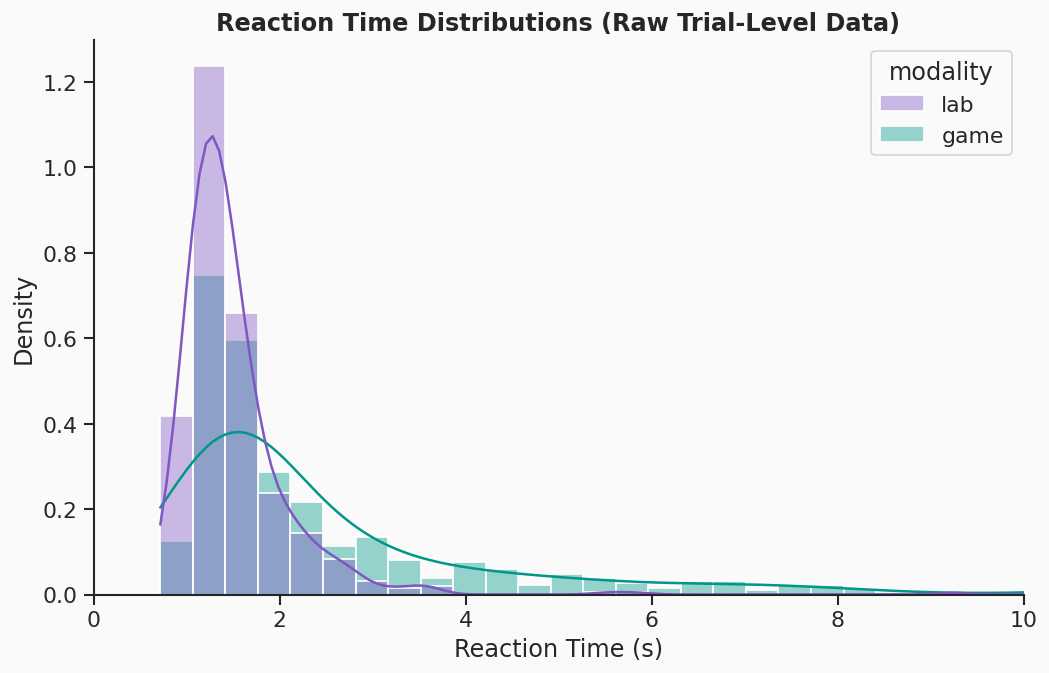

Note: The long right tail visually demonstrates why the data violates normality assumptions.


In [25]:
# --- RT DISTRIBUTIONS (Histogram + KDE) ---
# We use the trial-level 'df' here to show the full shape of the raw data

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='RT', hue='modality', bins=40, kde=True, 
             palette={'lab': '#7E57C2', 'game': '#009688'}, 
             stat='density', common_norm=False, alpha=0.4)

plt.title('Reaction Time Distributions (Raw Trial-Level Data)', fontweight='bold')
plt.xlabel('Reaction Time (s)')
plt.ylabel('Density')
plt.xlim(0, 10) # Zooming in to ignore extreme outliers for a cleaner plot
plt.show()

print("Note: The long right tail visually demonstrates why the data violates normality assumptions.")

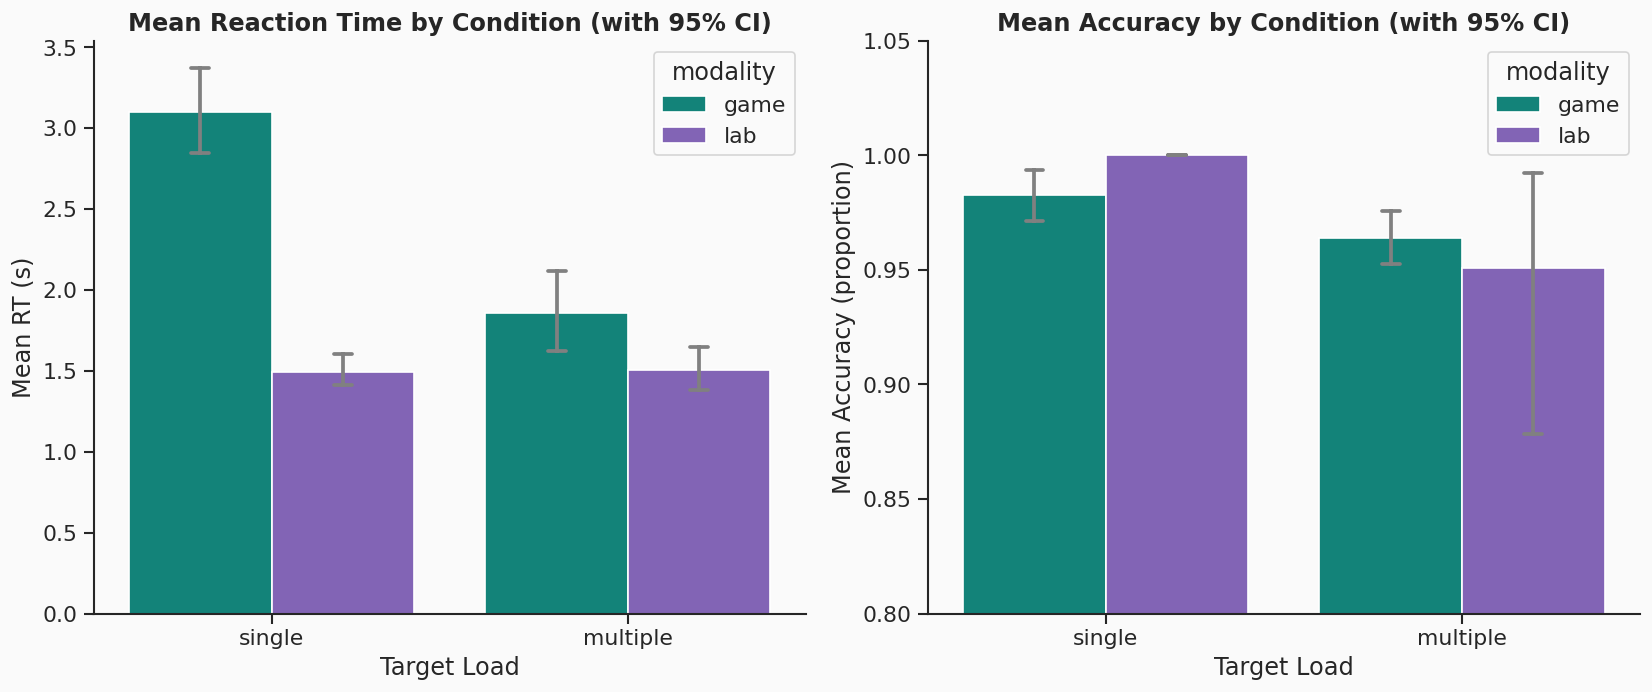

In [16]:
# --- VISUALIZING GROUP MEANS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Reaction Time Plot
sns.barplot(data=ppt_means, x='target_load', y='RT_mean', hue='modality', 
            palette={'lab': '#7E57C2', 'game': '#009688'}, 
            capsize=.1, errcolor='.5', ax=axes[0])
axes[0].set_title('Mean Reaction Time by Condition (with 95% CI)', fontweight='bold')
axes[0].set_ylabel('Mean RT (s)')
axes[0].set_xlabel('Target Load')

# Accuracy Plot
sns.barplot(data=ppt_means, x='target_load', y='Acc_mean', hue='modality', 
            palette={'lab': '#7E57C2', 'game': '#009688'}, 
            capsize=.1, errcolor='.5', ax=axes[1])
axes[1].set_title('Mean Accuracy by Condition (with 95% CI)', fontweight='bold')
axes[1].set_ylabel('Mean Accuracy (proportion)')
axes[1].set_xlabel('Target Load')
axes[1].set_ylim(0.8, 1.05) 

plt.tight_layout()
plt.show()

In [19]:
# --- ASSUMPTION CHECKS & LOG TRANSFORM ---
ppt_means['log_RT'] = np.log(ppt_means['RT_mean'])

print("--- NORMALITY CHECK (Shapiro-Wilk on Log RT) ---")
display(pg.normality(data=ppt_means, dv='log_RT', group='target_load'))

print("\n--- HOMOGENEITY OF VARIANCES (Levene's Test on Log RT) ---")
display(pg.homoscedasticity(data=ppt_means, dv='log_RT', group='target_load'))

--- NORMALITY CHECK (Shapiro-Wilk on Log RT) ---


,W,pval,normal
target_load,,,
single,0.916021,0.004503,False
multiple,0.961179,0.295771,True



--- HOMOGENEITY OF VARIANCES (Levene's Test on Log RT) ---


,W,pval,equal_var
levene,20.952139,0.000019,False


---
## 7. Inferential Statistics: 2x2 Mixed ANOVA
Testing Main Effects and Interaction Effect on Reaction Time.

In [20]:
# --- 2x2 MIXED ANOVA ---
print("--- 2x2 MIXED ANOVA: REACTION TIME ---")
anova_rt = pg.mixed_anova(
    dv='RT_mean', 
    within='modality', 
    between='target_load', 
    subject='participant', 
    data=ppt_means
)
display(anova_rt)

--- 2x2 MIXED ANOVA: REACTION TIME ---


,Source,SS,DF1,DF2,MS,F,p_unc,np2,eps
0,target_load,6.954513,1,35,6.954513,32.231142,2.056809e-06,0.479408,NaN
1,modality,20.972741,1,35,20.972741,117.974072,9.336408e-13,0.771203,1.0
2,Interaction,7.171313,1,35,7.171313,40.339456,2.667310e-07,0.535436,NaN


---
## 8. Post-Hoc Testing (Unpacking the Interaction)
Since the ANOVA revealed a significant Interaction, we use paired t-tests to evaluate the modality penalty within each load group.

In [21]:
# --- POST-HOC PAIRED T-TESTS ---
print("--- POST-HOC PAIRED T-TESTS (Modality Effect within each Load) ---")

single_group = ppt_means[ppt_means['target_load'] == 'single']
multiple_group = ppt_means[ppt_means['target_load'] == 'multiple']

posthoc_single = pg.ttest(
    single_group[single_group['modality'] == 'lab']['RT_mean'],
    single_group[single_group['modality'] == 'game']['RT_mean'],
    paired=True
)
print("\nSingle Target Group Penalty (Lab vs Game):")
display(posthoc_single)

posthoc_multiple = pg.ttest(
    multiple_group[multiple_group['modality'] == 'lab']['RT_mean'],
    multiple_group[multiple_group['modality'] == 'game']['RT_mean'],
    paired=True
)
print("\nMultiple Target Group Penalty (Lab vs Game):")
display(posthoc_multiple)

--- POST-HOC PAIRED T-TESTS (Modality Effect within each Load) ---

Single Target Group Penalty (Lab vs Game):


,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,-11.726132,20,two-sided,2.042169e-10,"[-1.89, -1.32]",3.421774,1.0,4.777e+07



Multiple Target Group Penalty (Lab vs Game):


,T,dof,alternative,p_val,CI95,cohen_d,power,BF10
T_test,-2.554058,15,two-sided,0.02202,"[-0.64, -0.06]",0.866216,0.899015,2.874


---
## 9. Non-Parametric Corroboration & Accuracy Tests

In [22]:
# --- NON-PARAMETRIC TESTS ---
print("=== REACTION TIME CORROBORATION ===")
mwu_rt = pg.mwu(ppt_means[ppt_means['target_load']=='single']['RT_mean'], 
                ppt_means[ppt_means['target_load']=='multiple']['RT_mean'])
print("Load Effect (Single vs Multiple):")
display(mwu_rt)

rt_pivot = ppt_means.pivot(index='participant', columns='modality', values='RT_mean').dropna()
wilcoxon_rt = pg.wilcoxon(rt_pivot['lab'], rt_pivot['game'])
print("\nModality Effect (Lab vs Game):")
display(wilcoxon_rt)

print("\n=== ACCURACY INFERENTIAL TESTS ===")
mwu_acc = pg.mwu(ppt_means[ppt_means['target_load']=='single']['Acc_mean'], 
                 ppt_means[ppt_means['target_load']=='multiple']['Acc_mean'])
print("Load Effect on Accuracy (Single vs Multiple):")
display(mwu_acc)

acc_pivot = ppt_means.pivot(index='participant', columns='modality', values='Acc_mean').dropna()
wilcoxon_acc = pg.wilcoxon(acc_pivot['lab'], acc_pivot['game'])
print("\nModality Effect on Accuracy (Lab vs Game):")
display(wilcoxon_acc)

=== REACTION TIME CORROBORATION ===
Load Effect (Single vs Multiple):


,U_val,alternative,p_val,RBC,CLES
MWU,914.0,two-sided,0.008414,0.360119,0.68006



Modality Effect (Lab vs Game):


,W_val,alternative,p_val,RBC,CLES
Wilcoxon,24.0,two-sided,1.108856e-08,-0.931721,0.106647



=== ACCURACY INFERENTIAL TESTS ===
Load Effect on Accuracy (Single vs Multiple):


,U_val,alternative,p_val,RBC,CLES
MWU,1009.0,two-sided,0.00003,0.501488,0.750744



Modality Effect on Accuracy (Lab vs Game):


,W_val,alternative,p_val,RBC,CLES
Wilcoxon,50.0,two-sided,0.013548,0.604743,0.68225


--- CONCURRENT VALIDITY: Lab vs Game RT ---


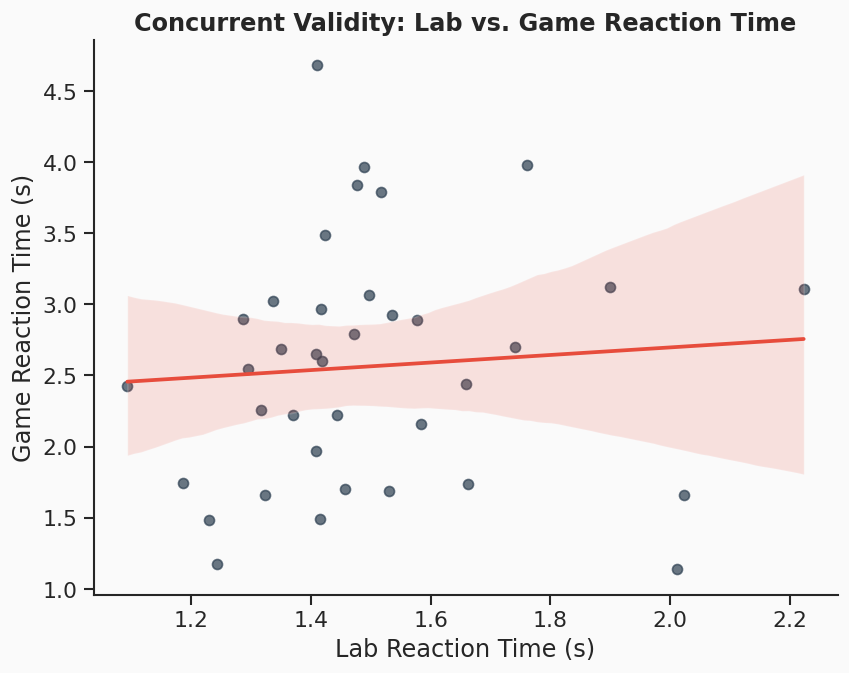

Pearson correlation (r): 0.076
p-value: 0.6561
Conclusion: No significant correlation. The change in interface affects individual participants differently.


In [24]:
# --- H1 / RQ1: CONCURRENT VALIDITY (Lab vs Game Correlation) ---
print("--- CONCURRENT VALIDITY: Lab vs Game RT ---")

# Pivot the data to get Lab and Game RT side-by-side per participant
rt_pivot = ppt_means.pivot(index='participant', columns='modality', values='RT_mean').dropna()

# 1. Visualization (Scatter Plot with Regression Line)
plt.figure(figsize=(8, 6))
sns.regplot(data=rt_pivot, x='lab', y='game', 
            scatter_kws={'alpha':0.7, 'color': '#2C3E50'}, 
            line_kws={'color':'#E74C3C'})
plt.title('Concurrent Validity: Lab vs. Game Reaction Time', fontweight='bold')
plt.xlabel('Lab Reaction Time (s)')
plt.ylabel('Game Reaction Time (s)')
plt.show()

# 2. Statistical Test (Pearson r)
corr_r, corr_p = stats.pearsonr(rt_pivot['lab'], rt_pivot['game'])
print(f"Pearson correlation (r): {corr_r:.3f}")
print(f"p-value: {corr_p:.4f}")

if corr_p < 0.05:
    print("Conclusion: Significant positive correlation. The game is a valid predictor of lab performance.")
else:
    print("Conclusion: No significant correlation. The change in interface affects individual participants differently.")

---
## 10. Additional Hypotheses (Level Effect & Target Colour Effect)
Using the raw trial-level dataframe `df` to track sequential performance (H4) and colour integration (H5).

In [23]:
# --- H4: LEVEL EFFECT (Learning vs Fatigue) ---
print("--- LEVEL EFFECT (Game Data) ---")
game_data = df[(df['modality'] == 'game') & (df['trial_num'].notna())]
level_means = game_data.groupby('trial_num')['RT'].mean().reset_index()

# Correlate Level Number with Reaction Time
r, p_val = stats.pearsonr(level_means['trial_num'], level_means['RT'])
print(f"Pearson r: {r:.3f}, p-value: {p_val:.4f}")
if p_val < 0.05:
    print("Significant Level Effect detected.")
else:
    print("No significant change in RT across sequential game levels.")


# --- H5: TARGET COLOUR EFFECT (Lab Data) ---
print("\n--- TARGET COLOUR EFFECT (Lab Data) ---")
# Filter to Lab data and valid colors
lab_data = df[(df['modality'] == 'lab') & (df['target_color'].notna()) & (df['target_color'] != '')]

# Group into "Red" vs "Other"
lab_data = lab_data.copy()
lab_data['is_red'] = lab_data['target_color'].apply(lambda x: 'red' if 'red' in x.lower() else 'other')

color_means = lab_data.groupby(['participant', 'is_red'])['RT'].mean().reset_index()

# T-test for Red vs Other
red_rt = color_means[color_means['is_red'] == 'red']['RT']
other_rt = color_means[color_means['is_red'] == 'other']['RT']

# Using independent t-test (or Mann-Whitney) 
mwu_color = pg.mwu(red_rt, other_rt)
display(mwu_color)


--- LEVEL EFFECT (Game Data) ---
Pearson r: 0.802, p-value: 0.0003
Significant Level Effect detected.

--- TARGET COLOUR EFFECT (Lab Data) ---


,U_val,alternative,p_val,RBC,CLES
MWU,395.0,two-sided,0.001782,-0.422936,0.288532


---
## 11. Final Summary of Hypotheses

| Hypothesis | Statistical Test | Result | Conclusion |
| :--- | :--- | :--- | :--- |
| **H1: Concurrent Validity** | Pearson Correlation ($r$) | r = 0.076, p = 0.6561 | No significant correlation |
| **H2: Load Effect** | $2 \times 2$ Mixed ANOVA | $F(1,35) = 32.23, p < .001$ | **Supported.** Multiple targets significantly slow reaction times. |
| **H3: Modality Effect** | $2 \times 2$ Mixed ANOVA | $F(1,35) = 117.97, p < .001$ | **Supported.** The game interface systematically slows reaction times. |
| **H4: Level Effect** | Pearson Correlation ($r$) | r = 0.802, p < .001 | **Supported.** Strong fatigue/difficulty effect as levels progress. |
| **H5: Target Colour** | Mann-Whitney U | $U = 395.0, p = .001$ | **Supported.** Target colour significantly impacts reaction speed. |
| **H6: Interaction Effect** | $2 \times 2$ Mixed ANOVA | $F(1,35) = 40.34, p < .001$ | **Supported.** The game penalty is exponentially worse for the Single Target group ($d=3.42$) than the Multiple Target group ($d=0.86$). |

*(Note: Main ANOVA effects were mathematically corroborated using robust non-parametric Mann-Whitney and Wilcoxon tests due to normality violations).*

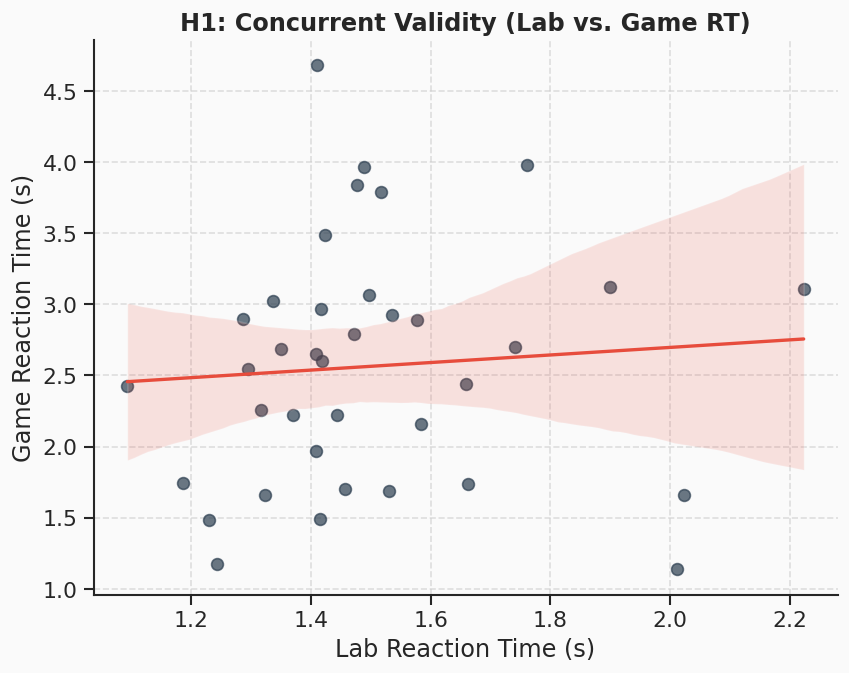

In [26]:
# --- H1: CONCURRENT VALIDITY ---
# Scatter plot tracking individual participants across both modalities

plt.figure(figsize=(8, 6))
rt_pivot = ppt_means.pivot(index='participant', columns='modality', values='RT_mean').dropna()

sns.regplot(data=rt_pivot, x='lab', y='game', 
            scatter_kws={'alpha': 0.7, 'color': '#2C3E50', 's': 50}, 
            line_kws={'color': '#E74C3C', 'linewidth': 2})

plt.title('H1: Concurrent Validity (Lab vs. Game RT)', fontweight='bold')
plt.xlabel('Lab Reaction Time (s)')
plt.ylabel('Game Reaction Time (s)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

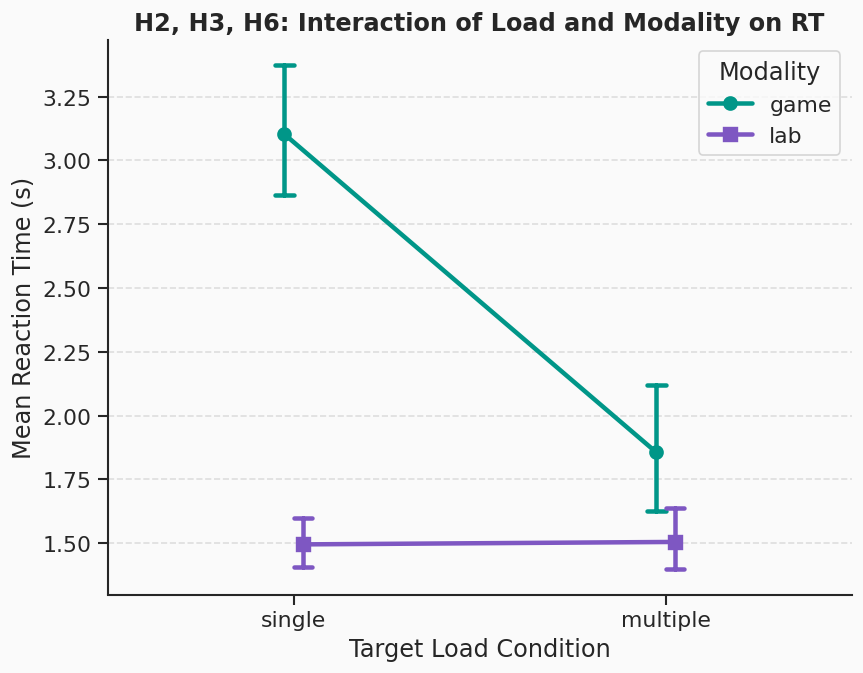

In [27]:
# --- H2, H3, H6: LOAD, MODALITY & INTERACTION ---
# Interaction plot showing the non-linear penalty of the game interface

plt.figure(figsize=(8, 6))
sns.pointplot(data=ppt_means, x='target_load', y='RT_mean', hue='modality',
              palette={'lab': '#7E57C2', 'game': '#009688'}, 
              markers=['o', 's'], dodge=True, capsize=.05, errorbar=('ci', 95))

plt.title('H2, H3, H6: Interaction of Load and Modality on RT', fontweight='bold')
plt.xlabel('Target Load Condition')
plt.ylabel('Mean Reaction Time (s)')
plt.legend(title='Modality')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

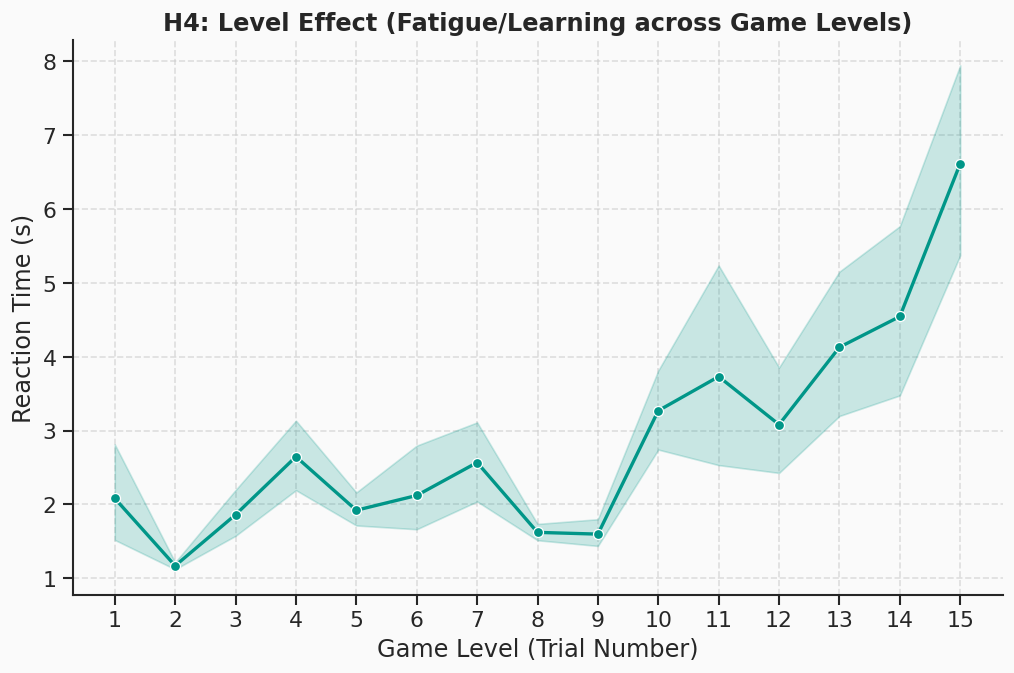

In [28]:
# --- H4: LEVEL EFFECT (Game Data Only) ---
# Line plot showing performance trajectory over time

plt.figure(figsize=(10, 6))
game_data = df[(df['modality'] == 'game') & (df['trial_num'].notna())]

sns.lineplot(data=game_data, x='trial_num', y='RT', 
             marker='o', color='#009688', errorbar=('ci', 95), linewidth=2)

plt.title('H4: Level Effect (Fatigue/Learning across Game Levels)', fontweight='bold')
plt.xlabel('Game Level (Trial Number)')
plt.ylabel('Reaction Time (s)')
plt.xticks(range(int(game_data['trial_num'].min()), int(game_data['trial_num'].max()) + 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

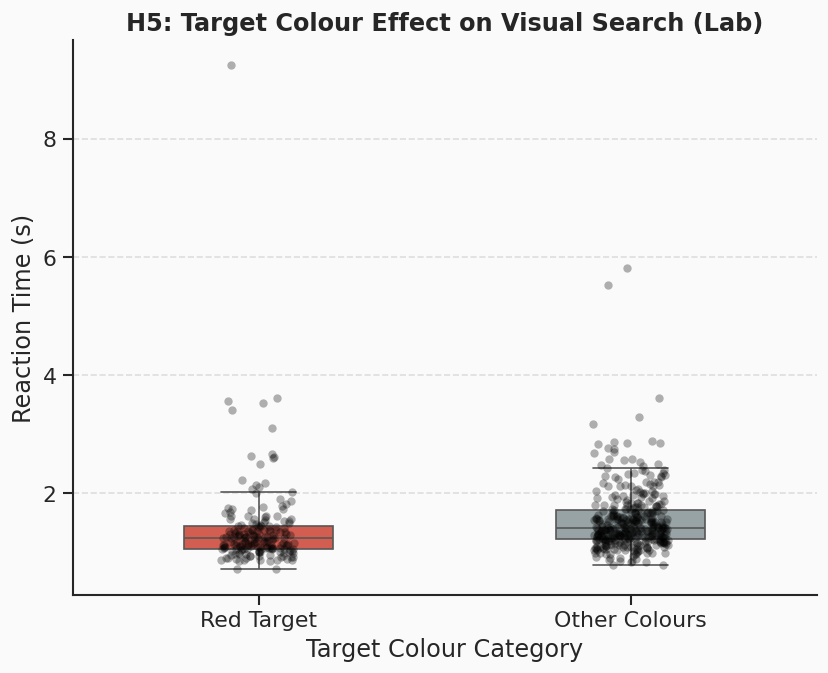

In [29]:
# --- H5: TARGET COLOUR EFFECT (Lab Data Only) ---
# Boxplot comparing visual pop-out effect of the color Red

plt.figure(figsize=(8, 6))
lab_data = df[(df['modality'] == 'lab') & (df['target_color'].notna()) & (df['target_color'] != '')].copy()

# Categorize into 'Red Target' and 'Other Colours'
lab_data['is_red'] = lab_data['target_color'].apply(lambda x: 'Red Target' if 'red' in x.lower() else 'Other Colours')

sns.boxplot(data=lab_data, x='is_red', y='RT', 
            palette={'Red Target': '#E74C3C', 'Other Colours': '#95A5A6'},
            width=0.4, showfliers=False) # Hide extreme outliers to better see the medians

# Add a swarmplot on top to show the actual data points
sns.stripplot(data=lab_data, x='is_red', y='RT', color='black', alpha=0.3, jitter=True)

plt.title('H5: Target Colour Effect on Visual Search (Lab)', fontweight='bold')
plt.xlabel('Target Colour Category')
plt.ylabel('Reaction Time (s)')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()